# 1. Setup

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from prophet import Prophet
import matplotlib.pyplot as plt
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

In [2]:
DATA_DIR = '/kaggle/input/competitions/datathon-2026-round-1/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
OUT_FILE = '/kaggle/working/submission.csv'

# 2. Load Data

Đọc dữ liệu bán hàng lịch sử, định dạng lại trường thời gian và xử lý dữ liệu lỗi.

In [3]:
sales = pd.read_csv(TRAIN_FILE, parse_dates = ['Date'])
sales['Y'] = sales.Date.dt.year
sales['Q'] = sales.Date.dt.quarter
sales['M'] = sales.Date.dt.month
sales['DW'] = sales.Date.dt.dayofweek
sales['D'] = sales.Date.dt.day

print('Train shape:', sales.shape)
print('Train date range:', sales.Date.min().date(), '->', sales.Date.max().date())
sales.head()

Train shape: (3833, 8)
Train date range: 2012-07-04 -> 2022-12-31


,Date,Revenue,COGS,Y,Q,M,DW,D
0,2012-07-04,5123547.94,3982991.19,2012,3,7,2,4
1,2012-07-05,2751773.45,2150580.23,2012,3,7,3,5
2,2012-07-06,3054029.42,2517632.84,2012,3,7,4,6
3,2012-07-07,2667930.94,2108246.62,2012,3,7,5,7
4,2012-07-08,2360851.90,1808622.79,2012,3,7,6,8


# 3. Inspect Data

Phân tích trực quan để xác định điểm gãy cấu trúc doanh thu do Covid-19 và đánh giá tính mùa vụ để làm tiền đề thiết kế mô hình.

## 3.1 Timeline Revenue & COGS

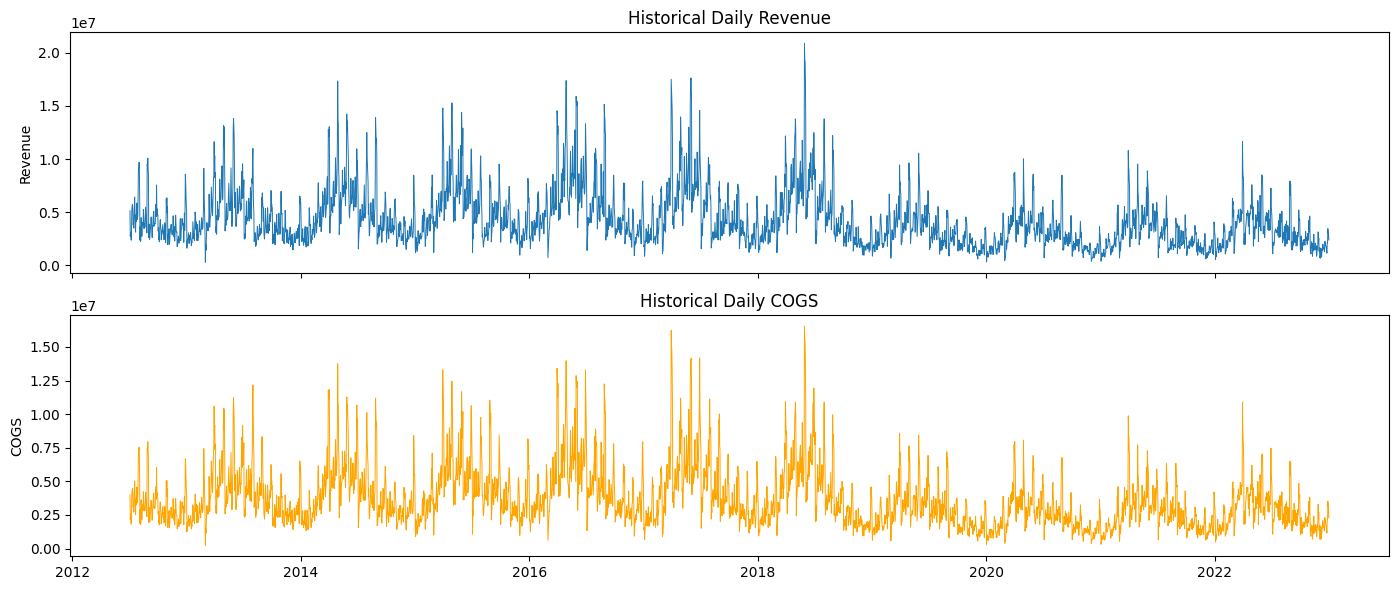

In [4]:
fig, axes = plt.subplots(2, 1, figsize = (14, 6), sharex = True)
axes[0].plot(sales['Date'], sales['Revenue'], lw = 0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')
axes[1].plot(sales['Date'], sales['COGS'], lw = 0.7, color = 'orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

## 3.2 Monthly seasonality

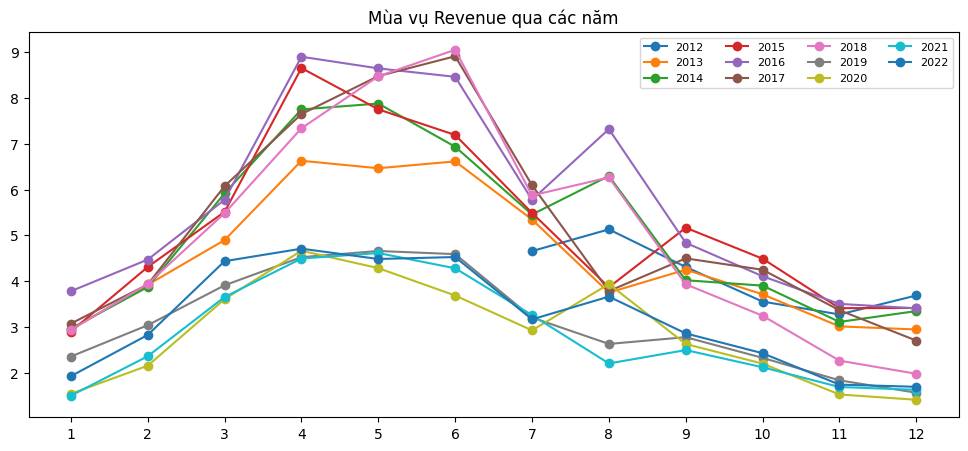

In [5]:
monthly = sales.groupby(['Y', 'M']).Revenue.mean().reset_index()
fig, ax = plt.subplots(figsize = (12, 5))
for y in sorted(sales.Y.unique()):
    d = monthly[monthly.Y == y]
    ax.plot(d.M, d.Revenue/1e6, marker = 'o', label = str(y))
ax.set_xticks(range(1, 13))
ax.legend(ncol = 4, fontsize = 8)
ax.set_title('Mùa vụ Revenue qua các năm')
plt.show()

## 3.3 Quarterly margin

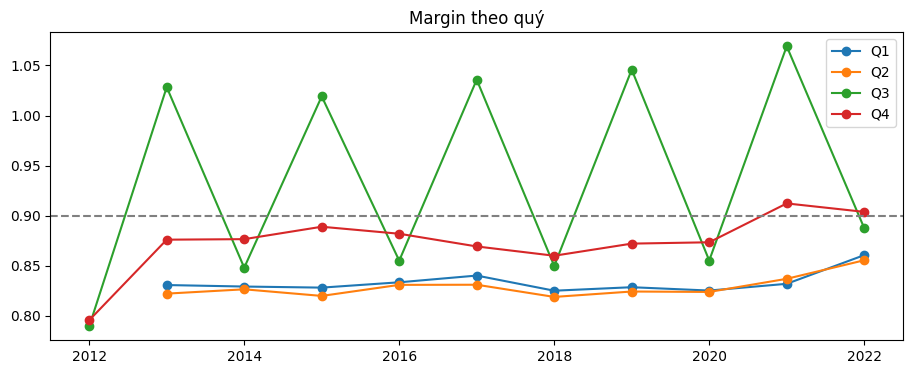

In [6]:
q_marg = sales.groupby(['Y', 'Q']).apply(
    lambda d: d.COGS.sum()/d.Revenue.sum(), include_groups = False).reset_index()
q_marg.columns = ['Y', 'Q', 'margin']

fig, ax = plt.subplots(figsize = (11, 4))
for q in [1, 2, 3, 4]:
    d = q_marg[q_marg.Q == q]
    ax.plot(d.Y, d.margin, marker = 'o', label = f'Q{q}')
ax.axhline(0.9, color = 'gray', ls = '--')
ax.set_title('Margin theo quý')
ax.legend()
plt.show()

# 4. Feature Engineering

Chỉ sử dụng các đặc trưng trích xuất từ Lịch (ngày lễ, khoảng cách đầu/cuối tháng, Fourier) để tránh rò rỉ dữ liệu khi dự báo xa 18 tháng.

In [7]:
# Lịch các chương trình khuyến mãi lớn của công ty
SCHEDULE = [
    ('spring_sale', 3, 18, 30, 12, True),
    ('mid_year',      6, 23, 29, 18, True),
    ('fall_launch',   8, 30, 32, 10, True),
    ('year_end',     11, 18, 45, 20, True),
    ('urban_blowout', 7, 30, 33, None, 'odd'),
    ('rural_special', 1, 30, 30, 15, 'odd'),
]

# Lịch ngày mùng 1 Tết thay đổi theo từng năm
TET_DATES = {
    2013:'2013-02-10', 2014:'2014-01-31', 2015:'2015-02-19',
    2016:'2016-02-08', 2017:'2017-01-28', 2018:'2018-02-16',
    2019:'2019-02-05', 2020:'2020-01-25', 2021:'2021-02-12',
    2022:'2022-02-01', 2023:'2023-01-22', 2024:'2024-02-10',
}

# Lịch các ngày lễ cố định
VN_HOLIDAYS = [
    (1,1,'new_year'), (3,8,'women_day'), (4,30,'giai_phong'),
    (5,1,'labor_day'), (9,2,'quoc_khanh'), (10,20,'vn_women_day'),
    (11,11,'dd_1111'), (12,12,'dd_1212'),
    (12,24,'christmas_eve'), (12,25,'christmas'),
]

In [8]:
# HÀM TRÍCH XUẤT ĐẶC TRƯNG CHÍNH
def build_features(dates):
    df = pd.DataFrame({'Date': dates})
    d = df['Date']

    # --- 1. Đặc trưng lịch bản ---
    # Nhận biết thời điểm trong năm
    df['year'] = d.dt.year
    df['month'] = d.dt.month
    df['day'] = d.dt.day
    df['dw'] = d.dt.dayofweek
    df['dy'] = d.dt.dayofyear
    df['quarter'] = d.dt.quarter
    # Doanh số e-commerce thường tăng vọt vào cuối tuần
    df['weekend'] = (df['dw']>=5).astype(int)
    # Tính toán khoảng cách đến đầu/cuối tháng
    df['days_to_eom'] = d.dt.days_in_month - df['day']
    df['days_from_som'] = df['day'] - 1
    df['dim'] = d.dt.days_in_month

    # Đánh dấu 3 ngày đầu và 3 ngày cuối tháng
    for k in [1,2,3]:
        df[f'is_last{k}'] = (df['days_to_eom'] <= k - 1).astype(int)
        df[f'is_first{k}'] = (df['days_from_som'] <= k - 1).astype(int)

    # --- 2. Đặc trưng xu hướng và giai đoạn (Trend + regime) ---
    # Đếm số ngày trôi qua kể từ mốc thời gian
    df['t_days']  = (d - pd.Timestamp('2020-01-01')).dt.days
    df['t_years'] = df['t_days']/365.25
    # Phân mảnh thời gian theo tác động của Covid-19
    df['regime_pre2019']  = (df['year']<=2018).astype(int)
    df['regime_2019']     = (df['year']==2019).astype(int)
    df['regime_post2019'] = (df['year']>=2020).astype(int)

    # --- 3. Biến đổi Fourier ---
    # Giúp mô hình bắt được tính mùa vụ
    tau = 2*np.pi

    # Tính theo chu kỳ năm
    for k in (1,2,3,4,5):
        df[f'sin_y{k}'] = np.sin(tau*k*df['dy']/365.25)
        df[f'cos_y{k}'] = np.cos(tau*k*df['dy']/365.25)
    # Tính theo chu kỳ tuần
    for k in (1,2):
        df[f'sin_w{k}'] = np.sin(tau*k*df['dw']/7.0)
        df[f'cos_w{k}'] = np.cos(tau*k*df['dw']/7.0)
    # Tính theo chu kỳ tháng
    for k in (1,2):
        df[f'sin_m{k}'] = np.sin(tau*k*(df['day']-1)/df['dim'])
        df[f'cos_m{k}'] = np.cos(tau*k*(df['day']-1)/df['dim'])

    # --- 4. Các ngày lễ và sự kiện ---
    # Đánh dấu các ngày lễ cố định
    for (m, dd_, name) in VN_HOLIDAYS:
        df[f'hol_{name}'] = ((df['month'] == m) & (df['day'] == dd_)).astype(int)

    # Xử lý ngày Tết Âm
    tet_lut = {y: pd.Timestamp(v) for y, v in TET_DATES.items()}
    def nearest_tet_diff(dd):
        # Lấy ngày Tết của năm ngoái, năm nay, và năm sau
        candidate = [tet_lut.get(dd.year), tet_lut.get(dd.year - 1), tet_lut.get(dd.year + 1)]
        candidate = [c for c in candidate if c is not None]

        # Chỉ tính ảnh hưởng của Tết trong bán kính 45 ngày
        valid = [(dd - c).days for c in candidate if abs((dd - c).days) <= 45]
        return min(valid) if valid else 999
    diffs = np.array([nearest_tet_diff(dd) for dd in d])
    # Tạo các flag liên quan đến Tết
    df['tet_days_diff'] = diffs
    df['tet_in_7'] = (np.abs(diffs) <= 7).astype(int)
    df['tet_in_14']     = (np.abs(diffs) <= 14).astype(int)
    df['tet_before_7']  = ((diffs >=- 7) & (diffs < 0)).astype(int)
    df['tet_after_7']   = ((diffs > 0) & (diffs <= 7)).astype(int)
    df['tet_on']        = (diffs == 0).astype(int)

    # Tìm ngày Black Friday
    def is_bf(dd):
        if dd.month != 11: return 0
        last = pd.Timestamp(year = dd.year, month = 11, day = 30)
        # Lùi lại tìm ngày thứ 6 gần nhất
        last_fri = last - pd.Timedelta(days = (last.dayofweek - 4) % 7)
        return int (dd == last_fri)
    df['hol_black_friday'] = [is_bf(dd) for dd in d]

    # --- 5. Lịch chương trình khuyến mãi ---
    yrs = sorted(set(df['year'].tolist()))
    for (name, start_month, start_day, duration, disc, recur_type) in SCHEDULE:
        in_prom = np.zeros(len(df), dtype = int)
        since = np.full(len(df), -1.0)
        until = np.full(len(df), -1.0)
        discount = np.zeros(len(df))
        for y in range(min(yrs) - 1, max(yrs) + 2):
            # Bỏ qua nếu chiến dịch chỉ diễn ra vào năm lẻ nhưng y là năm chẵn
            if recur_type == 'odd' and y % 2 == 0: continue

            start = pd.Timestamp(year = y, month = start_month, day = start_day)
            end   = start + pd.Timedelta(days = duration)

            # Đánh dấu các ngày nằm trong giai đoạn khuyến mãi
            mask = (d >= start) & (d <= end)
            in_prom[mask] = 1
            since[mask]   = (d[mask] - start).dt.days
            until[mask]   = (end - d[mask]).dt.days
            discount[mask]= disc or 0
        df[f'promo_{name}']       = in_prom
        df[f'promo_{name}_since'] = since
        df[f'promo_{name}_until'] = until
        df[f'promo_{name}_disc']  = discount

    # Flag đánh dấu năm lẻ
    df['is_odd_year'] = (df['year'] % 2).astype(int)
    return df

print('Test:', build_features(pd.date_range('2023-01-01', '2023-01-05')).shape)

Test: (5, 82)


# 5. Chuẩn bị Data train + test

In [9]:
# --- 1. Chuẩn bị tập Train ---
# Chạy toàn bộ cột Date trong lịch sử qua hàm để tạo bảng đặc trưng Train
feat = build_features(sales['Date'])
# Gắn thêm 2 cột Targets thực tế từ bảng sales sang để huấn luyện
feat['Revenue'] = sales['Revenue'].values
feat['COGS'] = sales['COGS'].values

# --- 2. Chuẩn bị tập Test ---
test_dates = pd.date_range('2023-01-01', '2024-07-01', freq = 'D')
test_df = build_features(test_dates)

# --- 3. Phân tách đặc trưng và biến mục tiêu ---
NON_FEATURES = {'Date','Revenue','COGS'}
cols = [c for c in feat.columns if c not in NON_FEATURES]

X_tr = feat[cols].values.astype(float)
X_te = test_df[cols].values.astype(float)
y_rev = np.log1p(feat['Revenue'].values)
y_cog = np.log1p(feat['COGS'].values)

# Lấy ra mảng lưu trữ năm của tập Train để phục vụ việc chia tập Cross-Validation theo thời gian ở bước sau
years = feat['Date'].dt.year.values

print(f'Training: {X_tr.shape}, Test: {X_te.shape}, Features: {len(cols)}')

Training: (3833, 81), Test: (548, 81), Features: 81


# 6. Đánh trọng số Mẫu (high_era)

Áp dụng hàm suy giảm hàm mũ để đánh trọng số. Ưu tiên cho các điểm dữ liệu gần với thời điểm dự báo năm 2023, giúp mô hình bắt trend mới nhất sau dịch.

In [10]:
w_full = np.full(len(years), 0.01)
w_full[(years >= 2014) & (years <= 2018)] = 1.0
print(f'Days with w = 1.0: {(w_full == 1.0).sum()}, w = 0.01: {(w_full == 0.01).sum()}')

Days with w = 1.0: 1826, w = 0.01: 2007


# 7. Model 1: Ridge Regression

Huấn luyện mô hình tuyến tính có kiểm soát để học các chu kỳ, làm mỏ neo giữ cho dự báo không bị chệch hướng xa.

In [11]:
# --- 1. Huấn luyện và chuẩn hóa dữ liệu ---
def train_ridge(X_train, y_train, alpha = 3.0):
    # Tính toán Mean và Std của tập Train
    mu = X_train.mean(axis = 0)
    sigma = X_train.std(axis = 0).replace(0, 1)
    # Chuẩn hóa Z-score cho tập Train: Z = (X - mu)/sigma
    X_scaled = (X_train - mu) / sigma
    # Khởi tạo và huấn luyện mô hình
    m = Ridge(alpha = alpha, random_state = 42)
    m.fit(X_scaled, y_train)
    return  m, (mu, sigma)

# --- 2. Dự báo trên tập Test ---
def predict_ridge(model, X_test_data, stats):
    mu, sigma = stats
    return model.predict((X_test_data - mu) / sigma)

ridge_rev, st_r = train_ridge(pd.DataFrame(X_tr, columns = cols), y_rev)
ridge_cog, st_c = train_ridge(pd.DataFrame(X_tr, columns = cols), y_cog)

p_rd_rev = np.expm1(predict_ridge(ridge_rev, pd.DataFrame(X_te, columns = cols), st_r))
p_rd_cog = np.expm1(predict_ridge(ridge_cog, pd.DataFrame(X_te, columns = cols), st_c))

print(f'Ridge Revenue: {p_rd_rev.mean():,.0f} VNĐ')
print(f'Ridge COGS: {p_rd_cog.mean():,.0f} VNĐ')

Ridge Revenue: 3,030,994 VNĐ
Ridge COGS: 2,721,462 VNĐ


# 8. Model 2: LightGBM

Mô hình này dùng để bắt các tương tác phi tuyến tính phức tạp giữa các đặc trưng, ví dụ như sự kết hợp giữa Ngày lễ, Cuối tháng và Các đợt khuyến mãi chồng chéo.

In [12]:
# --- 1. HyperParameters cho LightGBM ---
LGB_PARAMS = dict(
    objective = 'regression',
    metric = 'mae',
    learning_rate = 0.03,        # Tốc độ học chậm giúp mô hình hội tụ tốt hơn, tránh lố
    num_leaves = 63,             # Số lượng lá tối đa trên mỗi cây
    min_data_in_leaf = 30,       # Ràng buộc chống overfitting
    feature_fraction = 0.85,     # Lấy ngẫu nhiên 85% đặc trưng cho mỗi vòng lặp
    bagging_fraction = 0.85,     # Lấy ngẫu nhiên 85% dữ liệu để train mỗi cây
    bagging_freq = 5,            # Thực hiện bagging mỗi 5 vòng lặp
    lambda_l2 = 1.0,
    seed = 42,
    verbosity = -1,
)

# --- 2. Hàm huấn luyện model và tìm điểm dừng sớm ---
def train_lgb(X, y, w, num_boost_es = 5000, early_stop = 300):
    # Phân tách tập Validation
    # Early stopping trên internal holdout (180 ngày cuối)
    intern = pd.Timestamp('2022-07-04')
    fit_idx = (feat['Date'] <= intern).values
    ins_idx = (feat['Date'] > intern).values
    # Huấn luyện thử nghiệm để tìm số vòng lặp tối ưu
    booster_es = lgb.train(
        LGB_PARAMS,
        lgb.Dataset(X[fit_idx], y[fit_idx], weight = w[fit_idx]),
        num_boost_round = num_boost_es,
        valid_sets = [lgb.Dataset(X[ins_idx], y[ins_idx])],
        callbacks = [lgb.early_stopping(early_stop, verbose = False), lgb.log_evaluation(0)])
    # Retrain toàn bộ dữ liệu với số vòng lặp tối ưu
    booster_final = lgb.train(LGB_PARAMS, lgb.Dataset(X, y, weight = w), num_boost_round = booster_es.best_iteration)

    return booster_final, booster_es.best_iteration

In [13]:
print('Train LGB Revenue...')
bf_rev, it_rev = train_lgb(X_tr,y_rev, w_full)
print(f'best_iter = {it_rev}')

print('Train LGB COGS...')
bf_cog, it_cog = train_lgb(X_tr, y_cog, w_full)
print(f'best_iter={it_cog}')

p_lgb_rev = np.exp(bf_rev.predict(X_te))
p_lgb_cog = np.exp(bf_cog.predict(X_te))

print(f'LGB Revenue: {p_lgb_rev.mean():,.0f} VNĐ')
print(f'LGB COGS: {p_lgb_cog.mean():,.0f} VNĐ')

Train LGB Revenue...
best_iter = 224
Train LGB COGS...
best_iter=394
LGB Revenue: 3,370,261 VNĐ
LGB COGS: 2,894,426 VNĐ


# 9. Model 3: Prophet

Ứng dụng mô hình Prophet để phân rã xu hướng và ngoại suy tính mùa vụ cho 548 ngày trong tương lai.

In [14]:
# --- 1. Hàm chuẩn bị external regressors
def build_promo_regressors(dates):
    full = build_features(dates)
    promo_cols = [c for c in full.columns
                  if c.startswith('promo_') and 'since' not in c and 'until' not in c and 'disc' not in c]
    return full[['Date'] + promo_cols].rename(columns = {'Date': 'ds'})

# --- 2. Huấn luyện mô hình Prophet ---
def fit_prophet(train_df, post_regime_only = True):
    # Lọc bỏ dữ liệu trước Covid-19
    if post_regime_only:
        train_df = train_df[train_df['ds'] >= '2020-01-01']
    # Khởi tạo mô hình
    m = Prophet(yearly_seasonality = True,
                weekly_seasonality = True,
                daily_seasonality = False,
                seasonality_mode = 'multiplicative',
                changepoint_prior_scale = 0.05)
    # Chú ý đến các ngày có chiến dịch sale
    for col in [c for c in train_df.columns if c.startswith('promo_')]:
        m.add_regressor(col)
    m.fit(train_df)
    return m

In [15]:
print('Train Prophet Revenue...')
tdf_r = (pd.DataFrame({'ds': sales['Date'], 'y': np.log1p(sales['Revenue'])}).merge(build_promo_regressors(sales['Date']), on = 'ds'))
mp_r = fit_prophet(tdf_r)

print('Train Prophet COGS...')
tdf_c = (pd.DataFrame({'ds': sales['Date'], 'y': np.log1p(sales['COGS'])}).merge(build_promo_regressors(sales['Date']), on = 'ds'))
mp_c = fit_prophet(tdf_c)

vdf = (pd.DataFrame({'ds': test_df['Date']}).merge(build_promo_regressors(test_df['Date']), on = 'ds'))
p_pr_rev = np.expm1(mp_r.predict(vdf)['yhat'].values)
p_pr_cog = np.expm1(mp_c.predict(vdf)['yhat'].values)

print(f'Prophet Revenue: {p_pr_rev.mean():,.0f} VNĐ')
print(f'Prophet COGS: {p_pr_cog.mean():,.0f} VNĐ')

Train Prophet Revenue...


17:20:55 - cmdstanpy - INFO - Chain [1] start processing
17:20:55 - cmdstanpy - INFO - Chain [1] done processing


Train Prophet COGS...


17:20:56 - cmdstanpy - INFO - Chain [1] start processing
17:20:56 - cmdstanpy - INFO - Chain [1] done processing


Prophet Revenue: 3,569,616 VNĐ
Prophet COGS: 3,209,214 VNĐ


# 10. Hệ thống 8 mô hình chuyên biệt theo quý Q-Specialist (4 quý x 2 target)

Đặc thù của ngành Thương mại điện tử là tính mùa vụ cực gắt, ví dụ như quý 1 (Tết Âm lịch) có hành vi mua sắm khác hoàn toàn với quý 4 (các đợt mega sale như 11/11, 12/12). Nếu chỉ dùng 1 mô hình LightGBM chung, các quy luật này sẽ bị averaging out. Do đó, thiết lập 4 mô hình chuyên biệt cho 4 Quý (nhân với 2 targets Revenue/COGS = 8 mô hình).

In [16]:
# --- 1. Hàm huấn luyện mô hình chuyên biệt ---
def train_q_specialist(X, y, w_base, target_q, q_boost = 2.0):
    # Trích xuất mảng Quý từ chuỗi thời gian
    Q_train = feat['Date'].dt.quarter.values
    # Copy trọng số
    w = w_base.copy()
    # Tăng gấp đôi trọng số cho dữ liệu thuộc quý mục tiêu
    w[Q_train == target_q] *= q_boost
    booster_final, _ = train_lgb(X, y, w, num_boost_es = 3000, early_stop = 200)
    return booster_final

# --- 2. Huấn luyện 8 mô hình ---
spec_rev = {}
spec_cog = {}

print('Training 8 Q-Specialists model (LightGBM)...')
for q in [1, 2, 3, 4]:
    print(f'Train Quý {q} cho Revenue...')
    bf = train_q_specialist(X_tr, y_rev, w_full, q)
    spec_rev[q] = np.expm1(bf.predict(X_te))

    print(f'Train Quý {q} cho COGS...')
    bf = train_q_specialist(X_tr, y_cog, w_full, q)
    spec_cog[q] = np.expm1(bf.predict(X_te))

print('Done 8 specialists.')

Training 8 Q-Specialists model (LightGBM)...
Train Quý 1 cho Revenue...
Train Quý 1 cho COGS...
Train Quý 2 cho Revenue...
Train Quý 2 cho COGS...
Train Quý 3 cho Revenue...
Train Quý 3 cho COGS...
Train Quý 4 cho Revenue...
Train Quý 4 cho COGS...
Done 8 specialists.


In [17]:
Q_test = test_df['Date'].dt.quarter.values
# Khởi tạo mảng rỗng để chứa kết quả dự báo cuối cùng của LightGBM
preds_lgbm_rev = np.zeros(len(test_dates))
preds_lgbm_cog = np.zeros(len(test_dates))
for q in [1,2,3,4]:
    mask = Q_test == q
    preds_lgbm_rev[mask] = spec_rev[q][mask]
    preds_lgbm_cog[mask] = spec_cog[q][mask]
print(f'LGB Revenue/day: {preds_lgbm_rev.mean():,.0f} VNĐ')
print(f'LGB COGS/day: {preds_lgbm_cog.mean():,.0f} VNĐ')

LGB Revenue/day: 3,264,033 VNĐ
LGB COGS/day: 2,895,139 VNĐ


# 11. Ensemble 3 tầng + Calibration

In [18]:
# HyperParameters ensemble
alpha = 0.60 # specialist vs base LGB
cr = 1.26 # calibration revenue
cc = 1.32 # calibration COGS

# Tầng 1: hợp nhất LGB nội bộ
lgb_blend_rev = alpha * preds_lgbm_rev + (1 - alpha) * p_lgb_rev
lgb_blend_cog = alpha * preds_lgbm_cog + (1 - alpha) * p_lgb_cog

# Tầng 2: hợp nhất 3 mô hình
raw_rev = 0.1 * p_pr_rev + 0.1 * p_rd_rev + 0.8 * lgb_blend_rev
raw_cog = 0.1 * p_pr_cog + 0.1 * p_rd_cog + 0.8 * lgb_blend_cog

# Tầng 3: calibration
final_rev = cr * raw_rev
final_cog = cc * raw_cog

print(f'Final Revenue: {final_rev.mean():,.0f}')
print(f'Final COGS: {final_cog.mean():,.0f}')

Final Revenue: 4,164,654
Final COGS: 3,839,815


# 12. Submission

In [20]:
submission = pd.DataFrame({
    'Date': test_df['Date'].dt.strftime('%Y-%m-%d').values,
    'Revenue': final_rev,
    'COGS': final_cog,
})
submission.to_csv(OUT_FILE, index = False)
print(f'Saved {len(submission)} rows to {OUT_FILE}')
submission.head(10)

Saved 548 rows to /kaggle/working/submission.csv


,Date,Revenue,COGS
0,2023-01-01,2.460310e+06,2.619925e+06
1,2023-01-02,1.812750e+06,1.848039e+06
2,2023-01-03,1.572372e+06,1.432385e+06
3,2023-01-04,1.196962e+06,1.063519e+06
4,2023-01-05,1.369999e+06,1.185541e+06
5,2023-01-06,1.628278e+06,1.469877e+06
6,2023-01-07,1.579447e+06,1.504250e+06
7,2023-01-08,1.757801e+06,1.659047e+06
8,2023-01-09,2.232416e+06,2.159740e+06
9,2023-01-10,2.040818e+06,1.871799e+06
